In [1]:
!pip install -q pyspark==3.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [56]:
# =============================================================================
# BLOCK 1 — Configuration variables
# =============================================================================
# Pull everything from config.py. Fill that file in before running this script.
# In Colab you can either:
%run config.py
# or paste the config values directly into this cell.

from config import (
    event_hub_namespace,
    order_topic, order_consumer_conn_str,
    courier_topic, courier_consumer_conn_str,
    account_name, account_key, container_name,
)

<Figure size 1680x720 with 0 Axes>

In [57]:
!pip uninstall -y dataproc-spark-connect

In [58]:
# BLOCK 2 — Spark setup (Notebook 2, Cells 7-8 pattern)

import os
os.environ["PYSPARK_SUBMIT_ARGS"] = (
    "--packages "
    "org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.1,"
    "org.apache.spark:spark-avro_2.12:3.5.1,"
    "org.apache.hadoop:hadoop-azure:3.3.6,"
    "com.microsoft.azure:azure-storage:8.6.6 "
    "pyspark-shell"
)

from pyspark.sql import SparkSession
spark = (SparkSession.builder
    .appName("stream-m2")
    .config("spark.sql.shuffle.partitions", "4")
    .config(f"fs.azure.account.key.{account_name}.blob.core.windows.net", account_key)
    .getOrCreate())
print(spark.version)  # debe imprimir 3.5.1

3.5.1


In [59]:
# BLOCK 3 — Define Avro schemas as strings (Notebook 2, Cell 6 pattern)
# =============================================================================
# from_avro() takes a JSON schema string. These must match the producer
# schemas byte-for-byte (same field names, order, and namespaces).

order_schema_str = """
{
  "type": "record",
  "name": "OrderLifecycleEvent",
  "namespace": "fooddelivery.orders",
  "fields": [
    {"name": "event_id", "type": "string"},
    {"name": "order_id", "type": "string"},
    {"name": "restaurant_id", "type": "string"},
    {"name": "courier_id", "type": ["null", "string"], "default": null},
    {"name": "zone_id", "type": "string"},
    {"name": "event_type", "type": {
        "type": "enum", "name": "OrderEventType",
        "symbols": ["ORDER_PLACED","ORDER_CONFIRMED","ORDER_PREPARING",
                    "COURIER_ASSIGNED","COURIER_PICKED_UP",
                    "ORDER_DELIVERED","ORDER_CANCELLED"]
    }},
    {"name": "event_time", "type": {"type": "long", "logicalType": "timestamp-millis"}},
    {"name": "ingestion_time", "type": {"type": "long", "logicalType": "timestamp-millis"}},
    {"name": "order_value_cents", "type": "int"},
    {"name": "delivery_fee_cents", "type": "int"},
    {"name": "item_count", "type": "int"},
    {"name": "payment_method", "type": "string"},
    {"name": "platform", "type": "string"},
    {"name": "is_duplicate", "type": "boolean"},
    {"name": "estimated_delivery_time", "type": ["null", "long"], "default": null},
    {"name": "actual_delivery_time", "type": ["null", "long"], "default": null},
    {"name": "prep_duration_seconds", "type": ["null", "int"], "default": null},
    {"name": "delivery_duration_seconds", "type": ["null", "int"], "default": null},
    {"name": "customer_rating", "type": ["null", "int"], "default": null},
    {"name": "cancellation_reason", "type": ["null", "string"], "default": null}
  ]
}
"""

courier_schema_str = """
{
  "type": "record",
  "name": "CourierLocation",
  "namespace": "fooddelivery.couriers",
  "fields": [
    {"name": "event_id", "type": "string"},
    {"name": "courier_id", "type": "string"},
    {"name": "order_id", "type": ["null", "string"], "default": null},
    {"name": "zone_id", "type": "string"},
    {"name": "event_time", "type": {"type": "long", "logicalType": "timestamp-millis"}},
    {"name": "ingestion_time", "type": {"type": "long", "logicalType": "timestamp-millis"}},
    {"name": "latitude", "type": "double"},
    {"name": "longitude", "type": "double"},
    {"name": "speed_kmh", "type": "double"},
    {"name": "heading_degrees", "type": "double"},
    {"name": "courier_status", "type": "string"},
    {"name": "vehicle_type", "type": "string"},
    {"name": "battery_pct", "type": "int"},
    {"name": "network_type", "type": "string"},
    {"name": "is_duplicate", "type": "boolean"}
  ]
}
"""


In [60]:
# BLOCK 4 — Kafka config for order topic (Notebook 2, Cell 9 pattern)
# =============================================================================
order_kafka_conf = {
    "kafka.bootstrap.servers": f"{event_hub_namespace}.servicebus.windows.net:9093",
    "kafka.sasl.mechanism": "PLAIN",
    "kafka.security.protocol": "SASL_SSL",
    "kafka.sasl.jaas.config": f'org.apache.kafka.common.security.plain.PlainLoginModule required username="$ConnectionString" password="{order_consumer_conn_str}";',
    "subscribe": order_topic,
    "startingOffsets": "latest",
    "enable.auto.commit": "true ",
    "groupIdPrefix": "Stream_Analytics_",
    "auto.commit.interval.ms": "5000"
}



In [61]:
# BLOCK 5 — Read + deserialize + flatten for orders (Cells 10-13)
# =============================================================================
from pyspark.sql.functions import col
from pyspark.sql.avro.functions import from_avro

order_df = spark.readStream.format("kafka").options(**order_kafka_conf).load()
order_df = order_df.select(from_avro(order_df.value, order_schema_str).alias("data"))
order_df = order_df.select(
    col("data.event_id"),
    col("data.order_id"),
    col("data.restaurant_id"),
    col("data.courier_id"),
    col("data.zone_id"),
    col("data.event_type"),
    col("data.event_time"),
    col("data.ingestion_time"),
    col("data.order_value_cents"),
    col("data.delivery_fee_cents"),
    col("data.item_count"),
    col("data.payment_method"),
    col("data.platform"),
    col("data.is_duplicate"),
    col("data.estimated_delivery_time"),
    col("data.actual_delivery_time"),
    col("data.prep_duration_seconds"),
    col("data.delivery_duration_seconds"),
    col("data.customer_rating"),
    col("data.cancellation_reason"),
)


In [62]:
# BLOCK 6 — Kafka config for courier topic (Cell 9 pattern, different topic)
# =============================================================================
courier_kafka_conf = {
    "kafka.bootstrap.servers": f"{event_hub_namespace}.servicebus.windows.net:9093",
    "kafka.sasl.mechanism": "PLAIN",
    "kafka.security.protocol": "SASL_SSL",
    "kafka.sasl.jaas.config": f'org.apache.kafka.common.security.plain.PlainLoginModule required username="$ConnectionString" password="{courier_consumer_conn_str}";',
    "subscribe": courier_topic,
    "startingOffsets": "latest",
    "enable.auto.commit": "true ",
    "groupIdPrefix": "Stream_Analytics_",
    "auto.commit.interval.ms": "5000"
}


In [63]:
# BLOCK 7 — Read + deserialize + flatten for couriers (Cells 10-13)
# =============================================================================
courier_df = spark.readStream.format("kafka").options(**courier_kafka_conf).load()
courier_df = courier_df.select(from_avro(courier_df.value, courier_schema_str).alias("data"))
courier_df = courier_df.select(
    col("data.event_id"),
    col("data.courier_id"),
    col("data.order_id"),
    col("data.zone_id"),
    col("data.event_time"),
    col("data.ingestion_time"),
    col("data.latitude"),
    col("data.longitude"),
    col("data.speed_kmh"),
    col("data.heading_degrees"),
    col("data.courier_status"),
    col("data.vehicle_type"),
    col("data.battery_pct"),
    col("data.network_type"),
    col("data.is_duplicate"),
)

In [64]:
# BLOCK 8 — Define Blob output + checkpoint paths (Cell 14 pattern)
# =============================================================================
order_output_path     = f"wasbs://{container_name}@{account_name}.blob.core.windows.net/stream-output/orders/"
order_checkpoint_path = f"wasbs://{container_name}@{account_name}.blob.core.windows.net/checkpoint/orders/"
courier_output_path     = f"wasbs://{container_name}@{account_name}.blob.core.windows.net/stream-output/couriers/"
courier_checkpoint_path = f"wasbs://{container_name}@{account_name}.blob.core.windows.net/checkpoint/couriers/"

In [65]:
# BLOCK 9 — Memory sinks for live display (both feeds)
# =============================================================================
# In-memory temp views so we can SELECT * FROM ... in the display loop below.
query_orders_mem = order_df.writeStream \
    .format("memory") \
    .queryName("order_events_live") \
    .outputMode("append") \
    .start()

query_couriers_mem = courier_df.writeStream \
    .format("memory") \
    .queryName("courier_events_live") \
    .outputMode("append") \
    .start()


In [66]:
# BLOCK 10 — Parquet sinks to Blob (Cell 15 pattern, trigger 5 seconds)
# =============================================================================
query_orders_parquet = order_df.writeStream \
    .format("parquet") \
    .option("checkpointLocation", order_checkpoint_path) \
    .option("path", order_output_path) \
    .queryName("orders_to_blob") \
    .trigger(processingTime="5 seconds") \
    .start()

query_couriers_parquet = courier_df.writeStream \
    .format("parquet") \
    .option("checkpointLocation", courier_checkpoint_path) \
    .option("path", courier_output_path) \
    .queryName("couriers_to_blob") \
    .trigger(processingTime="5 seconds") \
    .start()

In [67]:
# BLOCK 11 — Display loop (Cell 28 polling pattern)
# =============================================================================
from time import sleep
from IPython.display import clear_output

sleep(15)  # let the first micro-batches land

N = 10
for i in range(N):
    clear_output(wait=True)
    print(f"--- Batch {i + 1}/{N} ---")
    print("ORDERS (most recent 20):")
    spark.sql(
        "SELECT event_id, order_id, zone_id, event_type, event_time "
        "FROM order_events_live ORDER BY event_time DESC"
    ).show(20, truncate=False)
    print("COURIERS (most recent 20):")
    spark.sql(
        "SELECT event_id, courier_id, zone_id, courier_status, speed_kmh, event_time "
        "FROM courier_events_live ORDER BY event_time DESC"
    ).show(20, truncate=False)
    sleep(10)

--- Batch 10/10 ---
ORDERS (most recent 20):
+------------------------------------+--------------+--------+-----------------+-----------------------+
|event_id                            |order_id      |zone_id |event_type       |event_time             |
+------------------------------------+--------------+--------+-----------------+-----------------------+
|evt_c035d50310084c278d4dc906294b0e0b|ord_d1f29c61b0|queens  |COURIER_ASSIGNED |2026-04-19 12:58:46.429|
|evt_48922331df02419ca8ba3aee06bb971f|ord_5fcea545dd|uptown  |ORDER_PREPARING  |2026-04-19 12:58:40.528|
|evt_35efe00286ff469987ad24106bc4ebc4|ord_400177d3c7|brooklyn|ORDER_DELIVERED  |2026-04-19 12:58:38.835|
|evt_1091cb1d8b774d4c97d2c90f275de638|ord_e3198ab90d|downtown|ORDER_CONFIRMED  |2026-04-19 12:58:35.641|
|evt_3ecfd8225a0646d2b880a99cf28bcf5d|ord_d1e91cd12f|midtown |ORDER_DELIVERED  |2026-04-19 12:58:34.639|
|evt_c4902b3705cd4665b82310bebb6dde2c|ord_c2f2dd3a6a|brooklyn|ORDER_PREPARING  |2026-04-19 12:58:34.047|
|evt_f7398

In [68]:
# BLOCK 12 — Verification: read Parquet back from Blob (Cell 22 pattern)
# =============================================================================
df_orders_result = spark.read.parquet(order_output_path).filter("event_type = 'ORDER_DELIVERED'")
df_orders_result.show(5)

df_couriers_result = spark.read.parquet(courier_output_path).filter("courier_status = 'ONLINE_DELIVERING'")
df_couriers_result.show(5)


+--------------------+--------------+-------------+-----------+--------+---------------+--------------------+--------------------+-----------------+------------------+----------+--------------+--------+------------+-----------------------+--------------------+---------------------+-------------------------+---------------+-------------------+
|            event_id|      order_id|restaurant_id| courier_id| zone_id|     event_type|          event_time|      ingestion_time|order_value_cents|delivery_fee_cents|item_count|payment_method|platform|is_duplicate|estimated_delivery_time|actual_delivery_time|prep_duration_seconds|delivery_duration_seconds|customer_rating|cancellation_reason|
+--------------------+--------------+-------------+-----------+--------+---------------+--------------------+--------------------+-----------------+------------------+----------+--------------+--------+------------+-----------------------+--------------------+---------------------+-------------------------+--

ANALYTICS FROM HERE

In [69]:
# Stop any active queries before starting analytics
for q in spark.streams.active:
    q.stop()
print("Cleared:", [q.name for q in spark.streams.active])

Cleared: []


Block A — Imports & setup:

In [70]:
from pyspark.sql.functions import (
    col, window, count, sum as _sum, avg, when,
    round as _round, min as _min, max as _max,  # add these
    percentile_approx  # useful for UC3 median delivery time
)
from pyspark.sql.types import TimestampType

orders_ts   = order_df.withColumn("event_ts", col("event_time").cast(TimestampType()))
couriers_ts = courier_df.withColumn("event_ts", col("event_time").cast(TimestampType()))

base_path = f"wasbs://{container_name}@{account_name}.blob.core.windows.net/analytics"
ckpt_path = f"wasbs://{container_name}@{account_name}.blob.core.windows.net/analytics-checkpoints"

print("Analytics helpers ready.")

Analytics helpers ready.


Block B — UC1: Revenue & Order Volume by Zone:

In [71]:
uc1_df = (
    orders_ts
    .filter(~col("is_duplicate"))
    .withWatermark("event_ts", "2 minutes")
    .groupBy(window("event_ts", "5 minutes"), col("zone_id"), col("platform"))
    .agg(
        count("order_id").alias("order_count"),
        _round(_sum("order_value_cents") / 100.0, 2).alias("total_revenue_eur"),
        _round(avg("order_value_cents") / 100.0, 2).alias("avg_order_value_eur"),
        _round(_sum("delivery_fee_cents") / 100.0, 2).alias("total_delivery_fees_eur"),
        _round(
            _sum("delivery_fee_cents") * 100.0 / when(_sum("order_value_cents") > 0, _sum("order_value_cents")).otherwise(1), 2
        ).alias("fee_to_revenue_pct"),
        count(when(col("payment_method") == "CASH", 1)).alias("cash_orders"),
    )
    .select(
        col("window.start").alias("window_start"),
        col("window.end").alias("window_end"),
        col("zone_id"),
        col("platform"),
        col("order_count"),
        col("total_revenue_eur"),
        col("avg_order_value_eur"),
        col("total_delivery_fees_eur"),
        col("fee_to_revenue_pct"),
        col("cash_orders"),
    )
)

uc1_mem = (uc1_df.writeStream
    .format("memory")
    .queryName("uc1_revenue_by_zone")
    .outputMode("update")
    .start()
)

uc1_parquet = (uc1_df.writeStream
    .format("parquet")
    .option("checkpointLocation", f"{ckpt_path}/uc1")
    .option("path", f"{base_path}/uc1_revenue_by_zone")
    .outputMode("append")
    .trigger(processingTime="30 seconds")
    .start()
)

print("UC1 started — Revenue & Order Volume by Zone")

UC1 started — Revenue & Order Volume by Zone


Block C — UC2: Cancellation Rate by Zone:

In [72]:
uc2_df = (
    orders_ts
    .filter(~col("is_duplicate"))
    .filter(col("event_type").isin("ORDER_PLACED", "ORDER_CANCELLED"))
    .withWatermark("event_ts", "3 minutes")
    .groupBy(window("event_ts", "10 minutes", "5 minutes"), col("zone_id"))
    .agg(
        count(when(col("event_type") == "ORDER_PLACED", 1)).alias("orders_placed"),
        count(when(col("event_type") == "ORDER_CANCELLED", 1)).alias("orders_cancelled"),
        count(when((col("event_type") == "ORDER_CANCELLED") &
                   (col("cancellation_reason") == "CUSTOMER_REQUEST"), 1)).alias("cancelled_by_customer"),
        count(when((col("event_type") == "ORDER_CANCELLED") &
                   (col("cancellation_reason") == "RESTAURANT_CLOSED"), 1)).alias("cancelled_restaurant"),
    )
    .withColumn(
        "cancellation_rate_pct",
        _round(
            col("orders_cancelled") * 100.0 /
            when(col("orders_placed") > 0, col("orders_placed")).otherwise(1),
            2
        )
    )
    .select(
        col("window.start").alias("window_start"),
        col("window.end").alias("window_end"),
        col("zone_id"),
        col("orders_placed"),
        col("orders_cancelled"),
        col("cancelled_by_customer"),
        col("cancelled_restaurant"),
        col("cancellation_rate_pct"),
    )
)

uc2_mem = (uc2_df.writeStream
    .format("memory")
    .queryName("uc2_cancellation_rate")
    .outputMode("update")
    .start()
)

uc2_parquet = (uc2_df.writeStream
    .format("parquet")
    .option("checkpointLocation", f"{ckpt_path}/uc2")
    .option("path", f"{base_path}/uc2_cancellation_rate")
    .outputMode("append")
    .trigger(processingTime="30 seconds")
    .start()
)

print("UC2 started — Cancellation Rate by Zone")

UC2 started — Cancellation Rate by Zone


Block D — UC3: Avg Delivery Duration by Zone:

In [77]:
uc3_df = (
    orders_ts
    .filter(~col("is_duplicate"))
    .filter(
        (col("event_type") == "ORDER_DELIVERED") &
        col("delivery_duration_seconds").isNotNull() &
        (col("delivery_duration_seconds") > 0) &
        (col("delivery_duration_seconds") < 3600)
    )
    .withWatermark("event_ts", "5 minutes")
    .groupBy(window("event_ts", "15 minutes"), col("zone_id"))
    .agg(
        count("order_id").alias("delivered_orders"),
        _round(avg("delivery_duration_seconds") / 60.0, 2).alias("avg_delivery_min"),
        _round(avg("prep_duration_seconds") / 60.0, 2).alias("avg_prep_min"),
        _round(avg("customer_rating"), 2).alias("avg_customer_rating"),
        count(when(
            col("actual_delivery_time") > col("estimated_delivery_time"), 1
        )).alias("late_deliveries"),
    )
    .select(
        col("window.start").alias("window_start"),
        col("window.end").alias("window_end"),
        col("zone_id"),
        col("delivered_orders"),
        col("avg_delivery_min"),
        col("avg_prep_min"),
        col("avg_customer_rating"),
        col("late_deliveries"),
    )
)

# Stop any previously running queries with these names to avoid IllegalArgumentException
for s in spark.streams.active:
    if s.name == "uc3_delivery_duration_mem":
        s.stop()
        print(f"Stopped existing memory query: {s.name}")
    if s.name == "uc3_delivery_duration_parquet":
        s.stop()
        print(f"Stopped existing parquet query: {s.name}")

uc3_mem = (uc3_df.writeStream
    .format("memory")
    .queryName("uc3_delivery_duration_mem") # Changed query name to avoid conflict
    .outputMode("update")
    .start()
)

uc3_parquet = (uc3_df.writeStream
    .format("parquet")
    .option("checkpointLocation", f"{ckpt_path}/uc3")
    .option("path", f"{base_path}/uc3_delivery_duration")
    .queryName("uc3_delivery_duration_parquet") # Added query name for clarity and to avoid conflict
    .outputMode("append")
    .trigger(processingTime="30 seconds")
    .start()
)

print("UC3 started — Avg Delivery Duration by Zone")

UC3 started — Avg Delivery Duration by Zone


Block E — UC4: Courier Fleet Health by Zone:

In [75]:
from pyspark.sql.functions import approx_count_distinct

uc4_df = (
    couriers_ts
    .filter(~col("is_duplicate"))
    .withWatermark("event_ts", "5 minutes")
    .groupBy(window("event_ts", "15 minutes"), col("zone_id"), col("vehicle_type"))
    .agg(
        approx_count_distinct("courier_id").alias("unique_couriers"),
        count("event_id").alias("total_pings"),
        count(when(col("courier_status") == "ONLINE_IDLE", 1)).alias("pings_idle"),
        count(when(col("courier_status") == "ONLINE_DELIVERING", 1)).alias("pings_delivering"),
        count(when(col("courier_status") == "ONLINE_PICKUP", 1)).alias("pings_on_pickup"),
        count(when(col("courier_status") == "OFFLINE", 1)).alias("pings_offline"),
        count(when(col("battery_pct") < 15, 1)).alias("low_battery_pings"),
        count(when(col("network_type") == "NO_SIGNAL", 1)).alias("no_signal_pings"),
        _round(avg("speed_kmh"), 2).alias("avg_speed_kmh"),
        _round(avg("battery_pct"), 1).alias("avg_battery_pct"),
    )
    .select(
        col("window.start").alias("window_start"),
        col("window.end").alias("window_end"),
        col("zone_id"),
        col("vehicle_type"),
        col("unique_couriers"),
        col("total_pings"),
        col("pings_idle"),
        col("pings_delivering"),
        col("pings_on_pickup"),
        col("pings_offline"),
        col("low_battery_pings"),
        col("no_signal_pings"),
        col("avg_speed_kmh"),
        col("avg_battery_pct"),
    )
)

uc4_mem = (uc4_df.writeStream
    .format("memory")
    .queryName("uc4_courier_availability")
    .outputMode("update")
    .start()
)

uc4_parquet = (uc4_df.writeStream
    .format("parquet")
    .option("checkpointLocation", f"{ckpt_path}/uc4")
    .option("path", f"{base_path}/uc4_courier_availability")
    .outputMode("append")
    .trigger(processingTime="30 seconds")
    .start()
)

print("UC4 started — Courier Fleet Health by Zone")

UC4 started — Courier Fleet Health by Zone


In [88]:
for q in spark.streams.active:
    if q.name in ["uc5_demand_supply"]:
        q.stop()
        print(f"Stopped: {q.name}")

In [89]:
# UC5a — Orders waiting per zone (stream 1)
orders_waiting_df = (
    orders_ts
    .filter(~col("is_duplicate"))
    .filter(col("event_type").isin("ORDER_PLACED", "ORDER_CONFIRMED", "ORDER_PREPARING"))
    .withWatermark("event_ts", "3 minutes")
    .groupBy(window("event_ts", "5 minutes"), col("zone_id"))
    .agg(count("order_id").alias("orders_waiting"))
    .select(
        col("window.start").alias("window_start"),
        col("zone_id"),
        col("orders_waiting")
    )
)

# UC5b — Couriers available per zone (stream 2)
couriers_available_df = (
    couriers_ts
    .filter(~col("is_duplicate"))
    .filter(col("courier_status") == "ONLINE_IDLE")
    .withWatermark("event_ts", "3 minutes")
    .groupBy(window("event_ts", "5 minutes"), col("zone_id"))
    .agg(approx_count_distinct("courier_id").alias("couriers_available"))
    .select(
        col("window.start").alias("window_start"),
        col("zone_id"),
        col("couriers_available")
    )
)

# Stop any previously running queries with these names to avoid IllegalArgumentException
for s in spark.streams.active:
    if s.name == "uc5_orders_waiting":
        s.stop()
        print(f"Stopped existing memory query: {s.name}")
    if s.name == "uc5_couriers_available":
        s.stop()
        print(f"Stopped existing memory query: {s.name}")
    if s.name == "uc5a_parquet_sink": # Assuming a name for the parquet sink
        s.stop()
        print(f"Stopped existing parquet query: {s.name}")
    if s.name == "uc5b_parquet_sink": # Assuming a name for the parquet sink
        s.stop()
        print(f"Stopped existing parquet query: {s.name}")

uc5a_mem = (orders_waiting_df.writeStream
    .format("memory")
    .queryName("uc5_orders_waiting")
    .outputMode("update")
    .start()
)

uc5b_mem = (couriers_available_df.writeStream
    .format("memory")
    .queryName("uc5_couriers_available")
    .outputMode("update")
    .start()
)

uc5a_parquet = (orders_waiting_df.writeStream
    .format("parquet")
    .option("checkpointLocation", f"{ckpt_path}/uc5a")
    .option("path", f"{base_path}/uc5_orders_waiting")
    .queryName("uc5a_parquet_sink") # Add a name for the parquet sink
    .outputMode("append")
    .trigger(processingTime="30 seconds")
    .start()
)

uc5b_parquet = (couriers_available_df.writeStream
    .format("parquet")
    .option("checkpointLocation", f"{ckpt_path}/uc5b")
    .option("path", f"{base_path}/uc5_couriers_available")
    .queryName("uc5b_parquet_sink") # Add a name for the parquet sink
    .outputMode("append")
    .trigger(processingTime="30 seconds")
    .start()
)

print("UC5 started — Demand/Supply Health per Zone (split streams)")

Stopped existing memory query: uc5_orders_waiting
Stopped existing memory query: uc5_couriers_available
UC5 started — Demand/Supply Health per Zone (split streams)


In [49]:
from pyspark.sql.functions import lag, abs as _abs, count as _count
from pyspark.sql.window import Window

# Compute avg delivery time per zone per 5-min tumbling window
uc6_base = (
    orders_ts
    .filter(~col("is_duplicate"))
    .filter(
        (col("event_type") == "ORDER_DELIVERED") &
        col("delivery_duration_seconds").isNotNull() &
        (col("delivery_duration_seconds") > 0) &
        (col("delivery_duration_seconds") < 3600)
    )
    .withWatermark("event_ts", "5 minutes")
    .groupBy(window("event_ts", "5 minutes"), col("zone_id"))
    .agg(
        _count("order_id").alias("delivered_count"),
        _round(avg("delivery_duration_seconds") / 60.0, 2).alias("avg_delivery_min"),
    )
    .select(
        col("window.start").alias("window_start"),
        col("window.end").alias("window_end"),
        col("zone_id"),
        col("delivered_count"),
        col("avg_delivery_min"),
    )
)

# Flag anomalies: current window avg > 1.5x the previous window avg
zone_window = Window.partitionBy("zone_id").orderBy("window_start")

uc6_mem = (uc6_base.writeStream
    .format("memory")
    .queryName("uc6_anomaly_raw")
    .outputMode("append")
    .start()
)

uc6_parquet = (uc6_base.writeStream
    .format("parquet")
    .option("checkpointLocation", f"{ckpt_path}/uc6")
    .option("path", f"{base_path}/uc6_anomaly_raw")
    .outputMode("append")
    .trigger(processingTime="30 seconds")
    .start()
)

print("UC6 started — Delivery Time Anomaly Detection")

UC6 started — Delivery Time Anomaly Detection


Block F — Live dashboard display:

In [21]:
import time
from IPython.display import clear_output

print("Waiting for first windows to populate...")
for _ in range(30):
    count = spark.sql("SELECT COUNT(*) as n FROM uc1_revenue_by_zone").collect()[0]["n"]
    if count > 0:
        print(f"Data ready! ({count} rows in UC1)")
        break
    time.sleep(10)

N = 5
for i in range(N):
    clear_output(wait=True)
    print(f"========== Analytics Dashboard — Refresh {i+1}/{N} ==========\n")

    print("UC1: Revenue & Order Volume by Zone (5 min window)")
    spark.sql("""
        SELECT zone_id, platform, window_start, order_count,
               total_revenue_eur, avg_order_value_eur, fee_to_revenue_pct, cash_orders
        FROM uc1_revenue_by_zone
        ORDER BY window_start DESC, total_revenue_eur DESC
    """).show(10, truncate=False)

    print("UC2: Cancellation Rate by Zone (10 min window)")
    spark.sql("""
        SELECT zone_id, window_start, orders_placed, orders_cancelled,
               cancelled_by_customer, cancelled_restaurant, cancellation_rate_pct
        FROM uc2_cancellation_rate
        ORDER BY window_start DESC, cancellation_rate_pct DESC
    """).show(10, truncate=False)

    print("UC3: Avg Delivery Duration by Zone (15 min window)")
    spark.sql("""
        SELECT zone_id, window_start, delivered_orders, avg_delivery_min,
               avg_prep_min, avg_customer_rating, late_deliveries
        FROM uc3_delivery_duration
        ORDER BY window_start DESC, avg_delivery_min DESC
    """).show(10, truncate=False)

    print("UC4: Courier Fleet Health by Zone & Vehicle (15 min window)")
    spark.sql("""
        SELECT zone_id, vehicle_type, unique_couriers, pings_idle, pings_delivering,
               pings_offline, low_battery_pings, avg_speed_kmh, avg_battery_pct
        FROM uc4_courier_availability
        ORDER BY window_start DESC, zone_id
    """).show(20, truncate=False)

    time.sleep(30)

========== Analytics Dashboard — Refresh 5/5 ==========

UC1: Revenue & Order Volume by Zone (5 min window)
+--------+--------+-------------------+-----------+-----------------+-------------------+------------------+-----------+
|zone_id |platform|window_start       |order_count|total_revenue_eur|avg_order_value_eur|fee_to_revenue_pct|cash_orders|
+--------+--------+-------------------+-----------+-----------------+-------------------+------------------+-----------+
|downtown|ANDROID |2026-04-19 12:00:00|8          |409.63           |51.2               |7.27              |1          |
|midtown |ANDROID |2026-04-19 12:00:00|6          |397.4            |66.23              |4.73              |0          |
|downtown|ANDROID |2026-04-19 12:00:00|7          |331.75           |47.39              |7.69              |1          |
|downtown|ANDROID |2026-04-19 12:00:00|6          |322.75           |53.79              |7.03              |1          |
|downtown|ANDROID |2026-04-19 12:00:00|5     

In [22]:
print("=== UC1 from Blob ===")
spark.read.parquet(f"{base_path}/uc1_revenue_by_zone").orderBy("window_start", ascending=False).show(10, truncate=False)

print("=== UC2 from Blob ===")
spark.read.parquet(f"{base_path}/uc2_cancellation_rate").orderBy("cancellation_rate_pct", ascending=False).show(10, truncate=False)

print("=== UC3 from Blob ===")
spark.read.parquet(f"{base_path}/uc3_delivery_duration").orderBy("avg_delivery_min", ascending=False).show(10, truncate=False)

print("=== UC4 from Blob ===")
spark.read.parquet(f"{base_path}/uc4_courier_availability").orderBy("window_start", ascending=False).show(10, truncate=False)

=== UC1 from Blob ===
+-------------------+-------------------+--------+-----------+-----------------+-------------------+-----------------------+
|window_start       |window_end         |zone_id |order_count|total_revenue_eur|avg_order_value_eur|total_delivery_fees_eur|
+-------------------+-------------------+--------+-----------+-----------------+-------------------+-----------------------+
|2026-04-18 16:40:00|2026-04-18 16:45:00|brooklyn|6          |238.43           |39.74              |27.85                  |
|2026-04-18 16:40:00|2026-04-18 16:45:00|midtown |34         |1699.73          |49.99              |132.6                  |
|2026-04-18 16:40:00|2026-04-18 16:45:00|uptown  |13         |760.97           |58.54              |51.77                  |
|2026-04-18 16:40:00|2026-04-18 16:45:00|queens  |14         |534.62           |38.19              |54.74                  |
|2026-04-18 16:40:00|2026-04-18 16:45:00|downtown|58         |2987.5           |51.51              |205

In [23]:
!pip install matplotlib seaborn -q
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

UC1 — Revenue by Zone (Bar Chart):

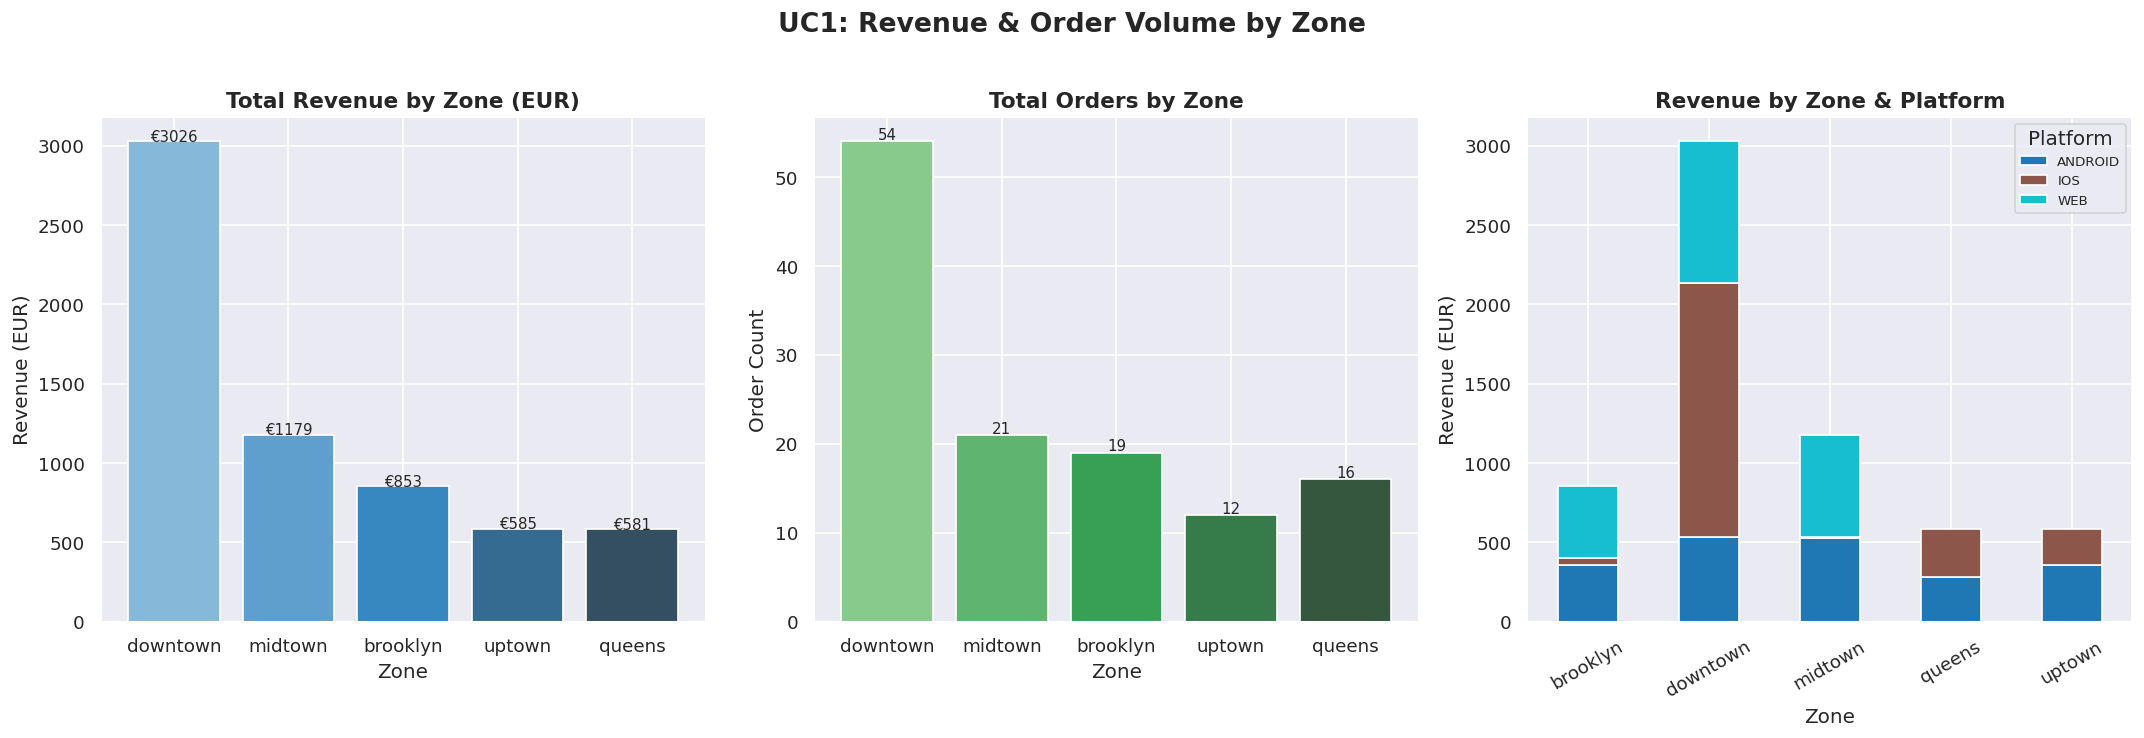

Saved: uc1_revenue_by_zone.png


In [79]:
uc1_pd = spark.sql("""
    SELECT zone_id,
           platform,
           SUM(order_count) as total_orders,
           SUM(total_revenue_eur) as total_revenue_eur,
           AVG(avg_order_value_eur) as avg_order_value_eur,
           AVG(fee_to_revenue_pct) as avg_fee_pct,
           SUM(cash_orders) as total_cash_orders
    FROM uc1_revenue_by_zone
    GROUP BY zone_id, platform
    ORDER BY total_revenue_eur DESC
""").toPandas()

uc1_zone = uc1_pd.groupby("zone_id").agg(
    total_revenue_eur=("total_revenue_eur", "sum"),
    total_orders=("total_orders", "sum"),
    avg_order_value_eur=("avg_order_value_eur", "mean"),
    avg_fee_pct=("avg_fee_pct", "mean"),
).reset_index().sort_values("total_revenue_eur", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Revenue by zone
bars = axes[0].bar(uc1_zone["zone_id"], uc1_zone["total_revenue_eur"],
                   color=sns.color_palette("Blues_d", len(uc1_zone)))
axes[0].set_title("Total Revenue by Zone (EUR)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Zone")
axes[0].set_ylabel("Revenue (EUR)")
for bar, val in zip(bars, uc1_zone["total_revenue_eur"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"€{val:.0f}", ha="center", fontsize=9)

# Order count by zone
bars2 = axes[1].bar(uc1_zone["zone_id"], uc1_zone["total_orders"],
                    color=sns.color_palette("Greens_d", len(uc1_zone)))
axes[1].set_title("Total Orders by Zone", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Zone")
axes[1].set_ylabel("Order Count")
for bar, val in zip(bars2, uc1_zone["total_orders"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(int(val)), ha="center", fontsize=9)

# Revenue split by platform (stacked bar)
platform_pivot = uc1_pd.pivot_table(index="zone_id", columns="platform",
                                     values="total_revenue_eur", aggfunc="sum").fillna(0)
platform_pivot.plot(kind="bar", stacked=True, ax=axes[2],
                    colormap="tab10")
axes[2].set_title("Revenue by Zone & Platform", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Zone")
axes[2].set_ylabel("Revenue (EUR)")
axes[2].legend(title="Platform", fontsize=8)
axes[2].tick_params(axis="x", rotation=30)

plt.suptitle("UC1: Revenue & Order Volume by Zone", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("uc1_revenue_by_zone.png", bbox_inches="tight")
plt.show()
print("Saved: uc1_revenue_by_zone.png")

UC2 — Cancellation Rate (Horizontal Bar):

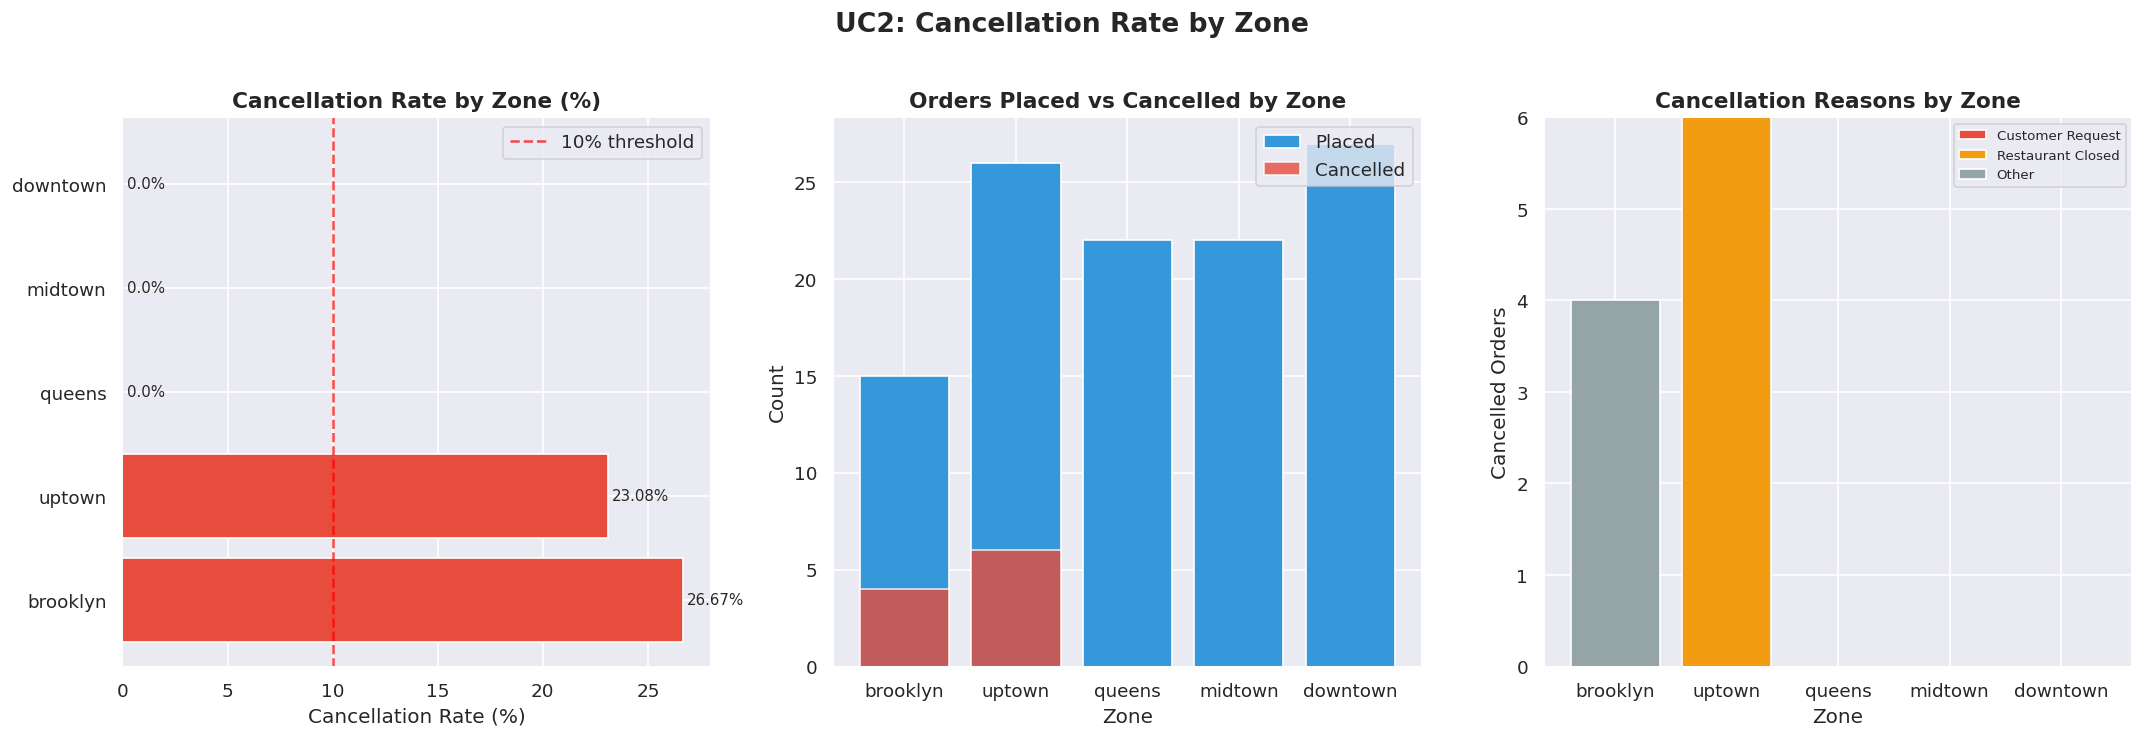

Saved: uc2_cancellation_rate.png


In [85]:
uc2_pd = spark.sql("""
    SELECT zone_id,
           CAST(SUM(orders_placed) AS DOUBLE) as total_placed,
           CAST(SUM(orders_cancelled) AS DOUBLE) as total_cancelled,
           CAST(SUM(cancelled_by_customer) AS DOUBLE) as by_customer,
           CAST(SUM(cancelled_restaurant) AS DOUBLE) as by_restaurant,
           CAST(ROUND(SUM(orders_cancelled) * 100.0 / NULLIF(SUM(orders_placed), 0), 2) AS DOUBLE) as cancellation_rate_pct
    FROM uc2_cancellation_rate
    GROUP BY zone_id
    ORDER BY cancellation_rate_pct DESC
""").toPandas().fillna(0)

uc2_pd["other"] = (uc2_pd["total_cancelled"] - uc2_pd["by_customer"] - uc2_pd["by_restaurant"]).clip(lower=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Cancellation rate horizontal bar
colors = ["#e74c3c" if r > 15 else "#f39c12" if r > 8 else "#2ecc71"
          for r in uc2_pd["cancellation_rate_pct"]]
bars = axes[0].barh(uc2_pd["zone_id"], uc2_pd["cancellation_rate_pct"], color=colors)
axes[0].set_title("Cancellation Rate by Zone (%)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cancellation Rate (%)")
axes[0].axvline(x=10, color="red", linestyle="--", alpha=0.7, label="10% threshold")
axes[0].legend()
for bar, val in zip(bars, uc2_pd["cancellation_rate_pct"]):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9)

# Placed vs cancelled
axes[1].bar(uc2_pd["zone_id"], uc2_pd["total_placed"], label="Placed", color="#3498db")
axes[1].bar(uc2_pd["zone_id"], uc2_pd["total_cancelled"], label="Cancelled", color="#e74c3c", alpha=0.8)
axes[1].set_title("Orders Placed vs Cancelled by Zone", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Zone")
axes[1].set_ylabel("Count")
axes[1].legend()

# Cancellation reasons
if uc2_pd["total_cancelled"].sum() > 0:
    axes[2].bar(uc2_pd["zone_id"], uc2_pd["by_customer"], label="Customer Request", color="#e74c3c")
    axes[2].bar(uc2_pd["zone_id"], uc2_pd["by_restaurant"],
                bottom=uc2_pd["by_customer"], label="Restaurant Closed", color="#f39c12")
    axes[2].bar(uc2_pd["zone_id"], uc2_pd["other"],
                bottom=uc2_pd["by_customer"] + uc2_pd["by_restaurant"],
                label="Other", color="#95a5a6")
    axes[2].set_ylabel("Cancelled Orders")
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, "No cancellations yet\nCheck back in a few minutes",
                 ha="center", va="center", fontsize=13, color="gray",
                 transform=axes[2].transAxes)

axes[2].set_title("Cancellation Reasons by Zone", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Zone")

plt.suptitle("UC2: Cancellation Rate by Zone", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("uc2_cancellation_rate.png", bbox_inches="tight")
plt.show()
print("Saved: uc2_cancellation_rate.png")

UC3 — Delivery Duration (Grouped Bar):

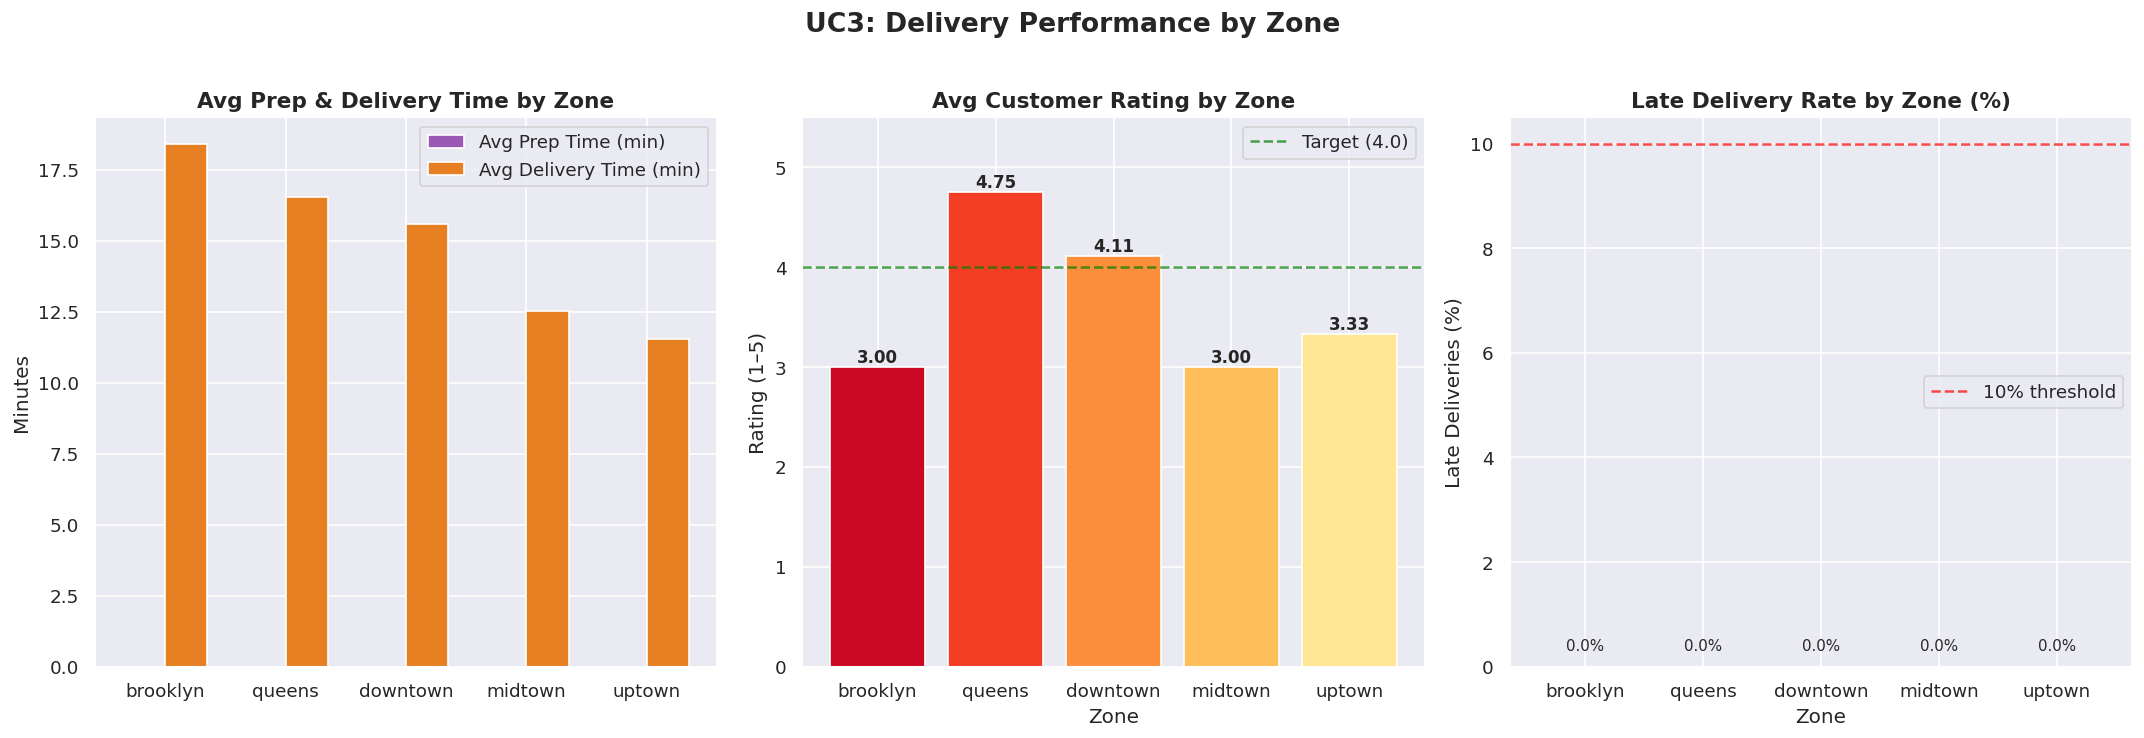

Saved: uc3_delivery_duration.png


In [81]:
uc3_pd = spark.sql("""
    SELECT zone_id,
           CAST(SUM(delivered_orders) AS DOUBLE) as total_delivered,
           CAST(ROUND(AVG(avg_delivery_min), 2) AS DOUBLE) as avg_delivery_min,
           CAST(ROUND(AVG(avg_prep_min), 2) AS DOUBLE) as avg_prep_min,
           CAST(ROUND(AVG(avg_customer_rating), 2) AS DOUBLE) as avg_rating,
           CAST(SUM(late_deliveries) AS DOUBLE) as total_late
    FROM uc3_delivery_duration
    GROUP BY zone_id
    ORDER BY avg_delivery_min DESC
""").toPandas().fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

if uc3_pd.empty or uc3_pd["total_delivered"].sum() == 0:
    for ax in axes:
        ax.text(0.5, 0.5, "No delivered orders yet\nWait a few more minutes and rerun",
                ha="center", va="center", fontsize=13, color="gray",
                transform=ax.transAxes)
else:
    uc3_pd["late_rate_pct"] = (uc3_pd["total_late"] / uc3_pd["total_delivered"].replace(0, 1) * 100).round(1)

    # Prep vs delivery grouped bar
    x = range(len(uc3_pd))
    width = 0.35
    axes[0].bar([i - width/2 for i in x], uc3_pd["avg_prep_min"],
                width, label="Avg Prep Time (min)", color="#9b59b6")
    axes[0].bar([i + width/2 for i in x], uc3_pd["avg_delivery_min"],
                width, label="Avg Delivery Time (min)", color="#e67e22")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(uc3_pd["zone_id"])
    axes[0].set_title("Avg Prep & Delivery Time by Zone", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Minutes")
    axes[0].legend()

    # Customer rating
    bars = axes[1].bar(uc3_pd["zone_id"], uc3_pd["avg_rating"],
                       color=sns.color_palette("YlOrRd_r", len(uc3_pd)))
    axes[1].set_ylim(0, 5.5)
    axes[1].set_title("Avg Customer Rating by Zone", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Zone")
    axes[1].set_ylabel("Rating (1–5)")
    axes[1].axhline(y=4.0, color="green", linestyle="--", alpha=0.7, label="Target (4.0)")
    axes[1].legend()
    for bar, val in zip(bars, uc3_pd["avg_rating"]):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

    # Late delivery rate
    late_colors = ["#e74c3c" if r > 20 else "#f39c12" if r > 10 else "#2ecc71"
                   for r in uc3_pd["late_rate_pct"]]
    bars2 = axes[2].bar(uc3_pd["zone_id"], uc3_pd["late_rate_pct"], color=late_colors)
    axes[2].set_title("Late Delivery Rate by Zone (%)", fontsize=13, fontweight="bold")
    axes[2].set_xlabel("Zone")
    axes[2].set_ylabel("Late Deliveries (%)")
    axes[2].axhline(y=10, color="red", linestyle="--", alpha=0.7, label="10% threshold")
    axes[2].legend()
    for bar, val in zip(bars2, uc3_pd["late_rate_pct"]):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f"{val}%", ha="center", fontsize=9)

plt.suptitle("UC3: Delivery Performance by Zone", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("uc3_delivery_duration.png", bbox_inches="tight")
plt.show()
print("Saved: uc3_delivery_duration.png")

UC4 — Courier Fleet Health (Stacked Bar + Heatmap):

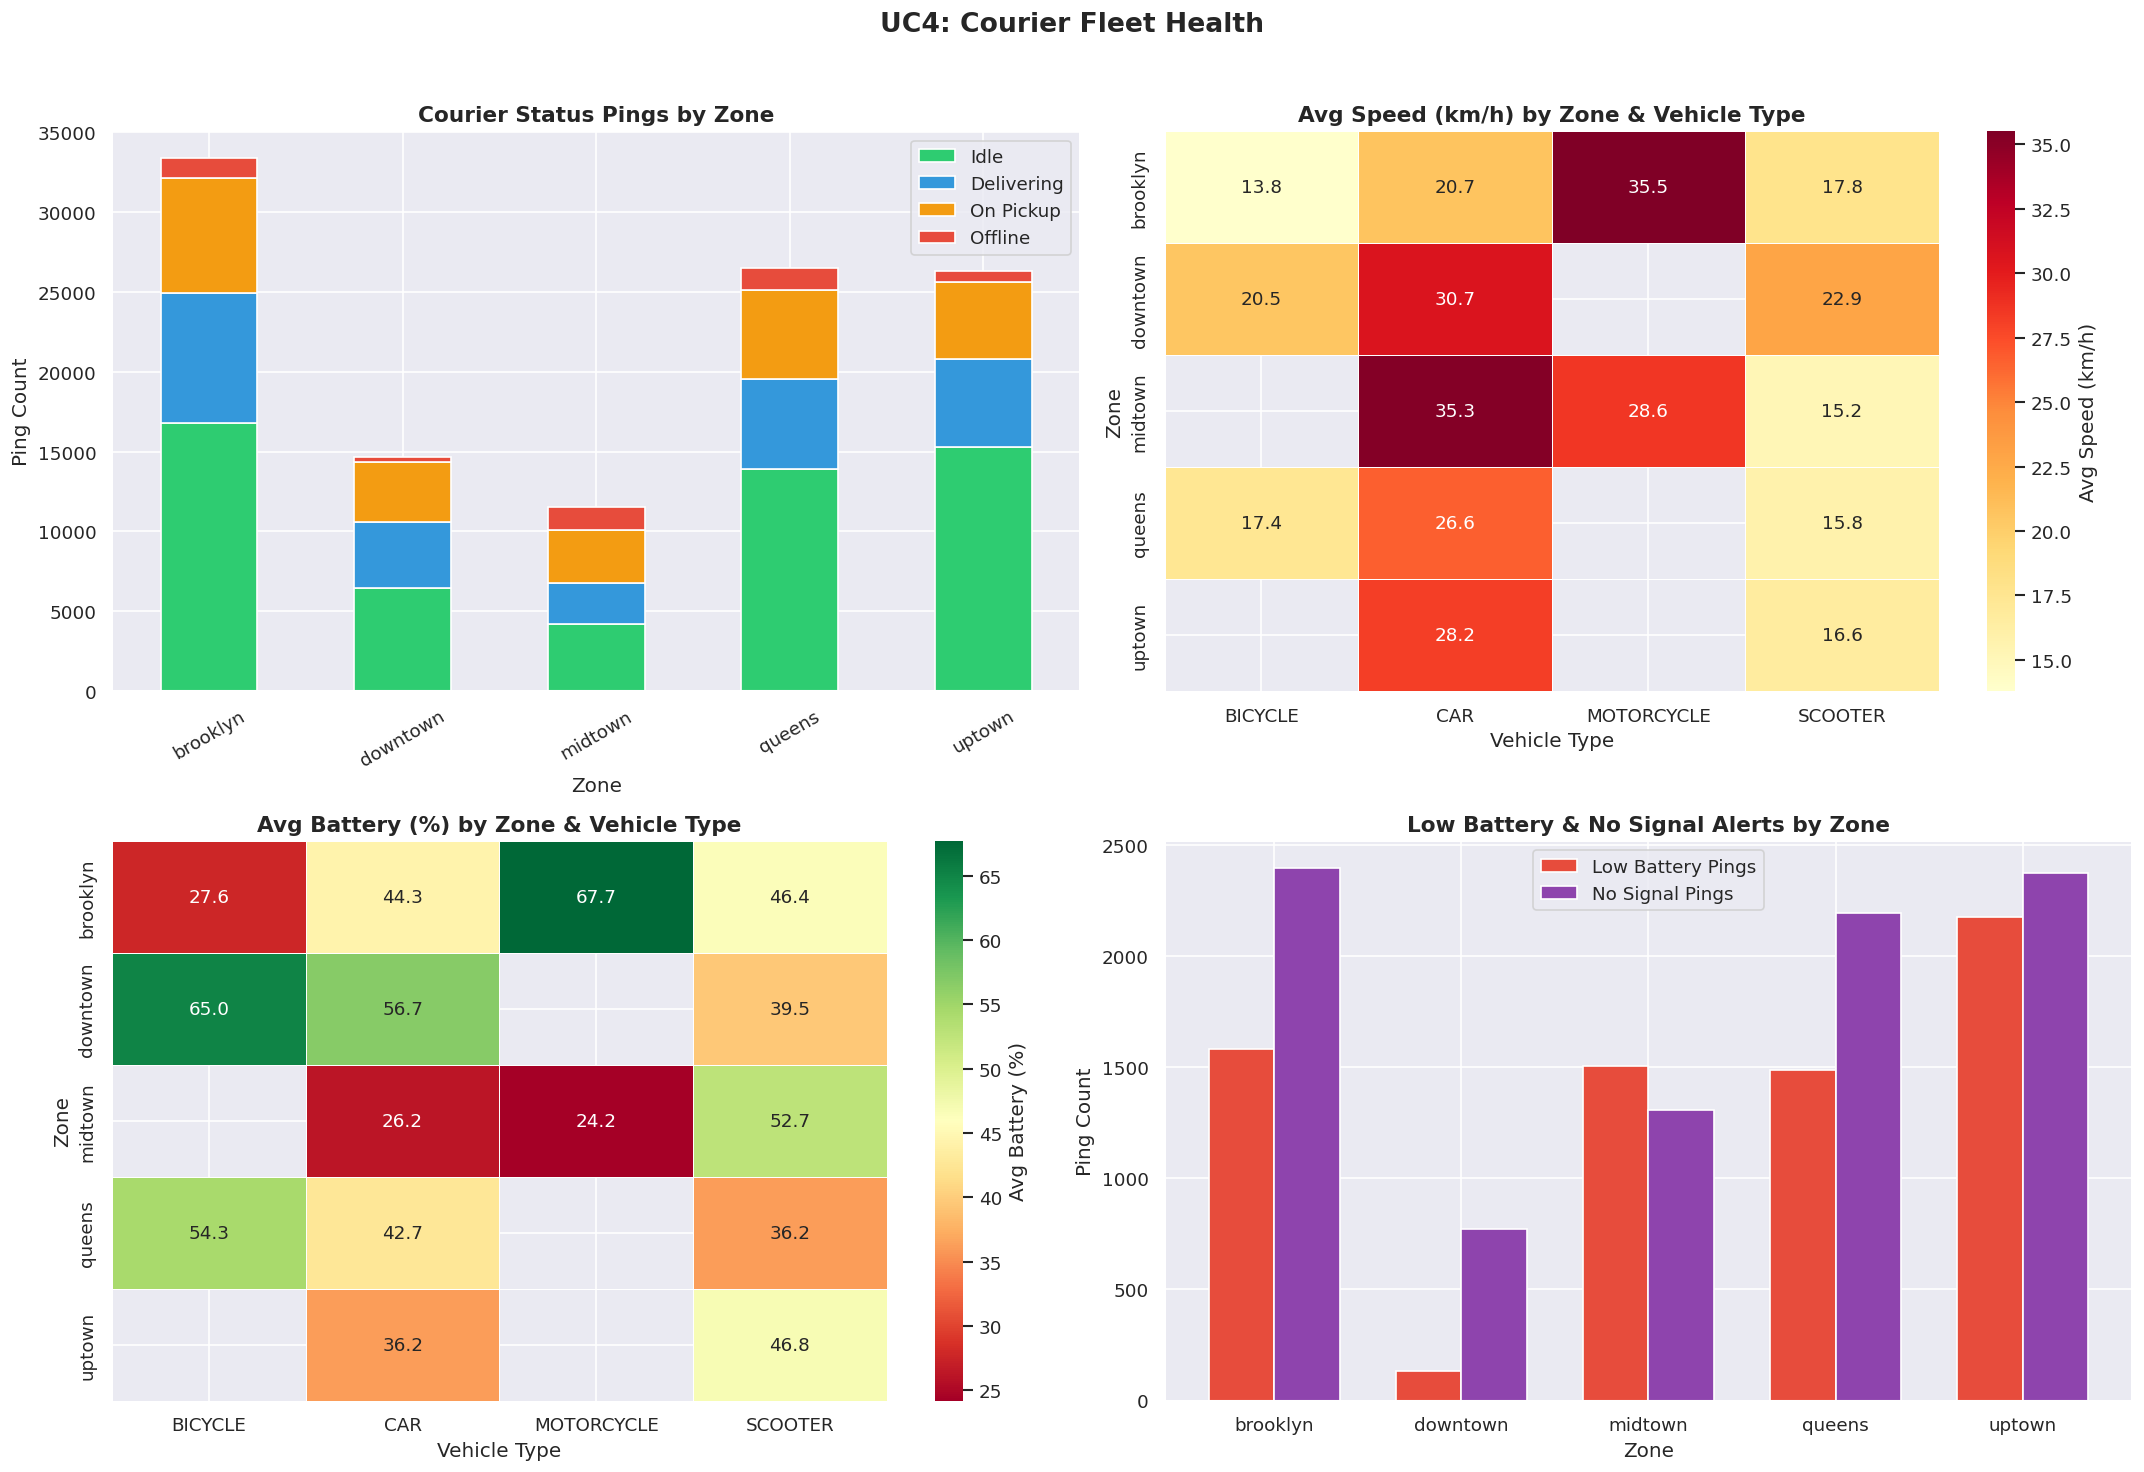

Saved: uc4_courier_fleet.png


In [45]:
uc4_pd = spark.sql("""
    SELECT zone_id, vehicle_type,
           SUM(unique_couriers) as unique_couriers,
           SUM(pings_idle) as idle,
           SUM(pings_delivering) as delivering,
           SUM(pings_on_pickup) as on_pickup,
           SUM(pings_offline) as offline,
           SUM(low_battery_pings) as low_battery,
           SUM(no_signal_pings) as no_signal,
           ROUND(AVG(avg_speed_kmh), 1) as avg_speed,
           ROUND(AVG(avg_battery_pct), 1) as avg_battery
    FROM uc4_courier_availability
    GROUP BY zone_id, vehicle_type
    ORDER BY zone_id, vehicle_type
""").toPandas()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Stacked bar — courier status pings by zone
uc4_zone = uc4_pd.groupby("zone_id")[["idle", "delivering", "on_pickup", "offline"]].sum()
uc4_zone.plot(kind="bar", stacked=True, ax=axes[0][0],
              color=["#2ecc71", "#3498db", "#f39c12", "#e74c3c"])
axes[0][0].set_title("Courier Status Pings by Zone", fontsize=13, fontweight="bold")
axes[0][0].set_xlabel("Zone")
axes[0][0].set_ylabel("Ping Count")
axes[0][0].legend(["Idle", "Delivering", "On Pickup", "Offline"], loc="upper right")
axes[0][0].tick_params(axis="x", rotation=30)

# Heatmap — avg speed by zone and vehicle type
pivot_speed = uc4_pd.pivot_table(values="avg_speed", index="zone_id",
                                  columns="vehicle_type", aggfunc="mean")
sns.heatmap(pivot_speed, ax=axes[0][1], annot=True, fmt=".1f",
            cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Avg Speed (km/h)"})
axes[0][1].set_title("Avg Speed (km/h) by Zone & Vehicle Type", fontsize=13, fontweight="bold")
axes[0][1].set_xlabel("Vehicle Type")
axes[0][1].set_ylabel("Zone")

# Heatmap — avg battery by zone and vehicle type
pivot_battery = uc4_pd.pivot_table(values="avg_battery", index="zone_id",
                                    columns="vehicle_type", aggfunc="mean")
sns.heatmap(pivot_battery, ax=axes[1][0], annot=True, fmt=".1f",
            cmap="RdYlGn", linewidths=0.5,
            cbar_kws={"label": "Avg Battery (%)"})
axes[1][0].set_title("Avg Battery (%) by Zone & Vehicle Type", fontsize=13, fontweight="bold")
axes[1][0].set_xlabel("Vehicle Type")
axes[1][0].set_ylabel("Zone")

# Low battery + no signal alerts by zone
uc4_alerts = uc4_pd.groupby("zone_id")[["low_battery", "no_signal"]].sum().reset_index()
x = range(len(uc4_alerts))
width = 0.35
axes[1][1].bar([i - width/2 for i in x], uc4_alerts["low_battery"],
               width, label="Low Battery Pings", color="#e74c3c")
axes[1][1].bar([i + width/2 for i in x], uc4_alerts["no_signal"],
               width, label="No Signal Pings", color="#8e44ad")
axes[1][1].set_xticks(x)
axes[1][1].set_xticklabels(uc4_alerts["zone_id"])
axes[1][1].set_title("Low Battery & No Signal Alerts by Zone", fontsize=13, fontweight="bold")
axes[1][1].set_xlabel("Zone")
axes[1][1].set_ylabel("Ping Count")
axes[1][1].legend()

plt.suptitle("UC4: Courier Fleet Health", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("uc4_courier_fleet.png", bbox_inches="tight")
plt.show()
print("Saved: uc4_courier_fleet.png")

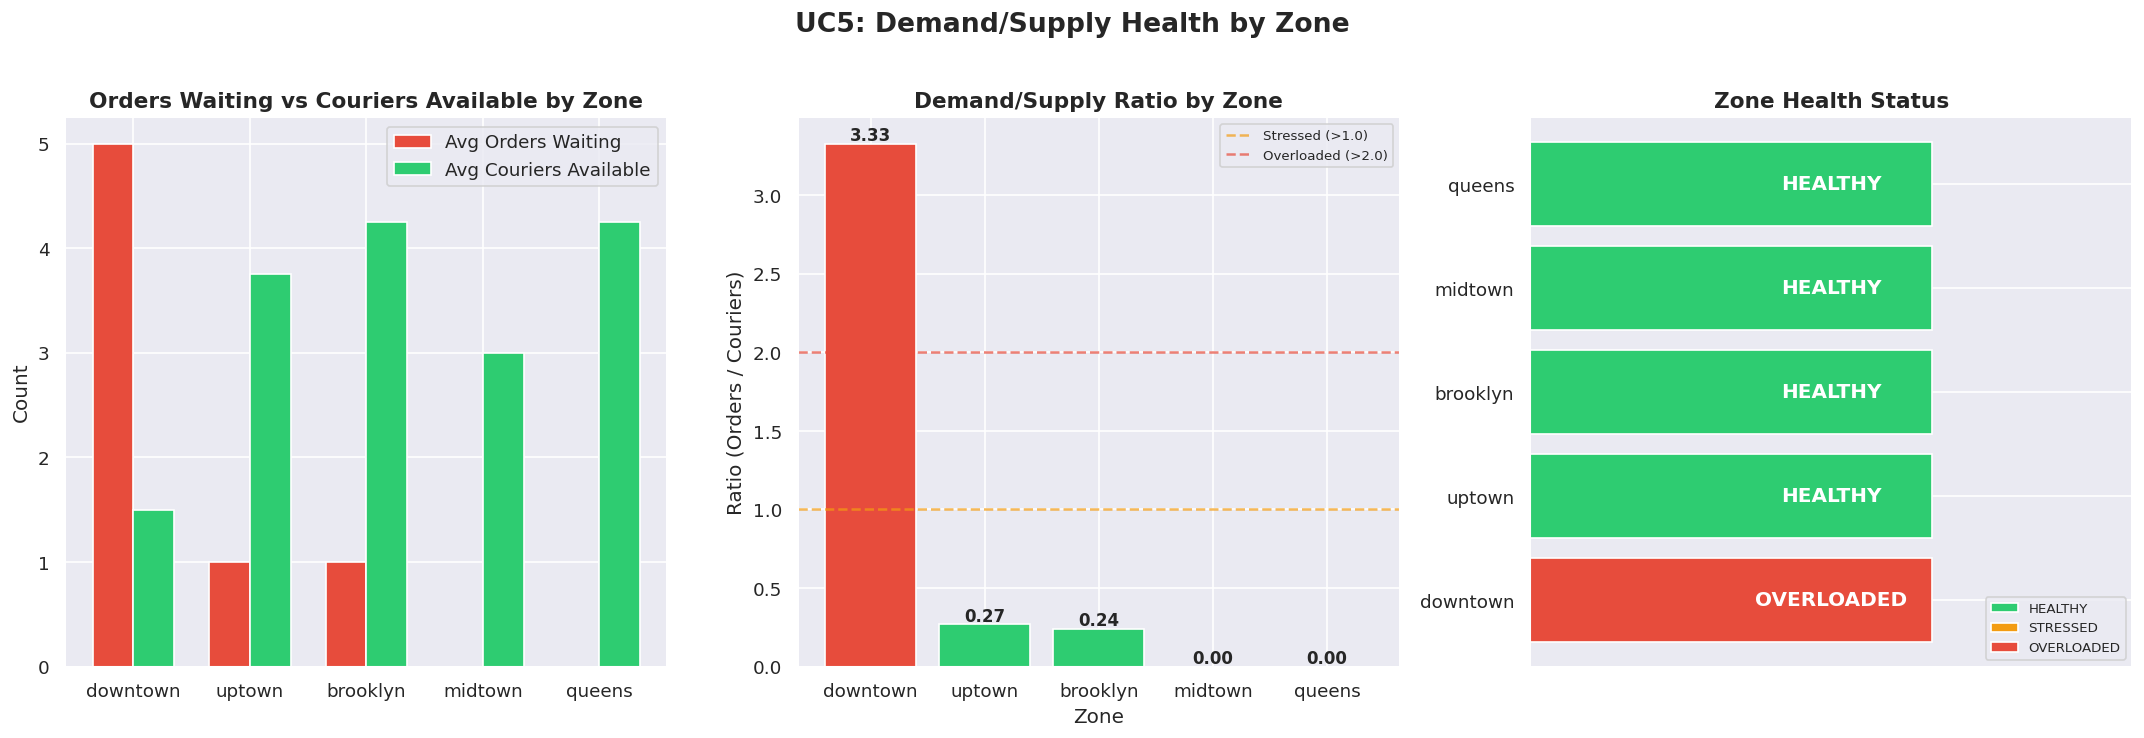

Saved: uc5_demand_supply.png


In [91]:
uc5_orders = spark.sql("""
    SELECT zone_id,
           CAST(AVG(orders_waiting) AS DOUBLE) as avg_orders_waiting
    FROM uc5_orders_waiting
    GROUP BY zone_id
""").toPandas().fillna(0)

uc5_couriers = spark.sql("""
    SELECT zone_id,
           CAST(AVG(couriers_available) AS DOUBLE) as avg_couriers_available
    FROM uc5_couriers_available
    GROUP BY zone_id
""").toPandas().fillna(0)

# Join in pandas instead of Spark stream-stream join
uc5_pd = uc5_orders.merge(uc5_couriers, on="zone_id", how="outer").fillna(0)
uc5_pd["demand_supply_ratio"] = (
    uc5_pd["avg_orders_waiting"] /
    uc5_pd["avg_couriers_available"].replace(0, 1)
).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

if uc5_pd.empty or uc5_pd["avg_orders_waiting"].sum() == 0:
    for ax in axes:
        ax.text(0.5, 0.5, "No demand/supply data yet\nWait a few more minutes and rerun",
                ha="center", va="center", fontsize=13, color="gray",
                transform=ax.transAxes)
else:
    uc5_pd = uc5_pd.sort_values("demand_supply_ratio", ascending=False)

    # Chart 1 — Orders waiting vs couriers available
    x = range(len(uc5_pd))
    width = 0.35
    axes[0].bar([i - width/2 for i in x], uc5_pd["avg_orders_waiting"],
                width, label="Avg Orders Waiting", color="#e74c3c")
    axes[0].bar([i + width/2 for i in x], uc5_pd["avg_couriers_available"],
                width, label="Avg Couriers Available", color="#2ecc71")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(uc5_pd["zone_id"])
    axes[0].set_title("Orders Waiting vs Couriers Available by Zone", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Chart 2 — Demand/supply ratio
    ratio_colors = ["#e74c3c" if r > 2.0 else "#f39c12" if r > 1.0 else "#2ecc71"
                    for r in uc5_pd["demand_supply_ratio"]]
    bars = axes[1].bar(uc5_pd["zone_id"], uc5_pd["demand_supply_ratio"], color=ratio_colors)
    axes[1].axhline(y=1.0, color="#f39c12", linestyle="--", alpha=0.7, label="Stressed (>1.0)")
    axes[1].axhline(y=2.0, color="#e74c3c", linestyle="--", alpha=0.7, label="Overloaded (>2.0)")
    axes[1].set_title("Demand/Supply Ratio by Zone", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Zone")
    axes[1].set_ylabel("Ratio (Orders / Couriers)")
    axes[1].legend(fontsize=8)
    for bar, val in zip(bars, uc5_pd["demand_supply_ratio"]):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

    # Chart 3 — Zone health status
    def get_status(r):
        if r > 2.0: return "OVERLOADED"
        if r > 1.0: return "STRESSED"
        return "HEALTHY"

    status_colors = {"OVERLOADED": "#e74c3c", "STRESSED": "#f39c12", "HEALTHY": "#2ecc71"}
    uc5_pd["status"] = uc5_pd["demand_supply_ratio"].apply(get_status)
    bar_colors = [status_colors[s] for s in uc5_pd["status"]]

    axes[2].barh(uc5_pd["zone_id"], [1] * len(uc5_pd), color=bar_colors)
    axes[2].set_xlim(0, 1.5)
    axes[2].set_title("Zone Health Status", fontsize=13, fontweight="bold")
    axes[2].set_xticks([])
    for i, (_, row) in enumerate(uc5_pd.iterrows()):
        axes[2].text(0.75, i, row["status"], ha="center", va="center",
                     fontsize=12, fontweight="bold", color="white")

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="#2ecc71", label="HEALTHY"),
                       Patch(facecolor="#f39c12", label="STRESSED"),
                       Patch(facecolor="#e74c3c", label="OVERLOADED")]
    axes[2].legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.suptitle("UC5: Demand/Supply Health by Zone", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("uc5_demand_supply.png", bbox_inches="tight")
plt.show()
print("Saved: uc5_demand_supply.png")

=== Delivery Time Anomalies Detected ===
Total anomalies found: 0
Empty DataFrame
Columns: [zone_id, window_start, prev_avg, avg_delivery_min, pct_change]
Index: []


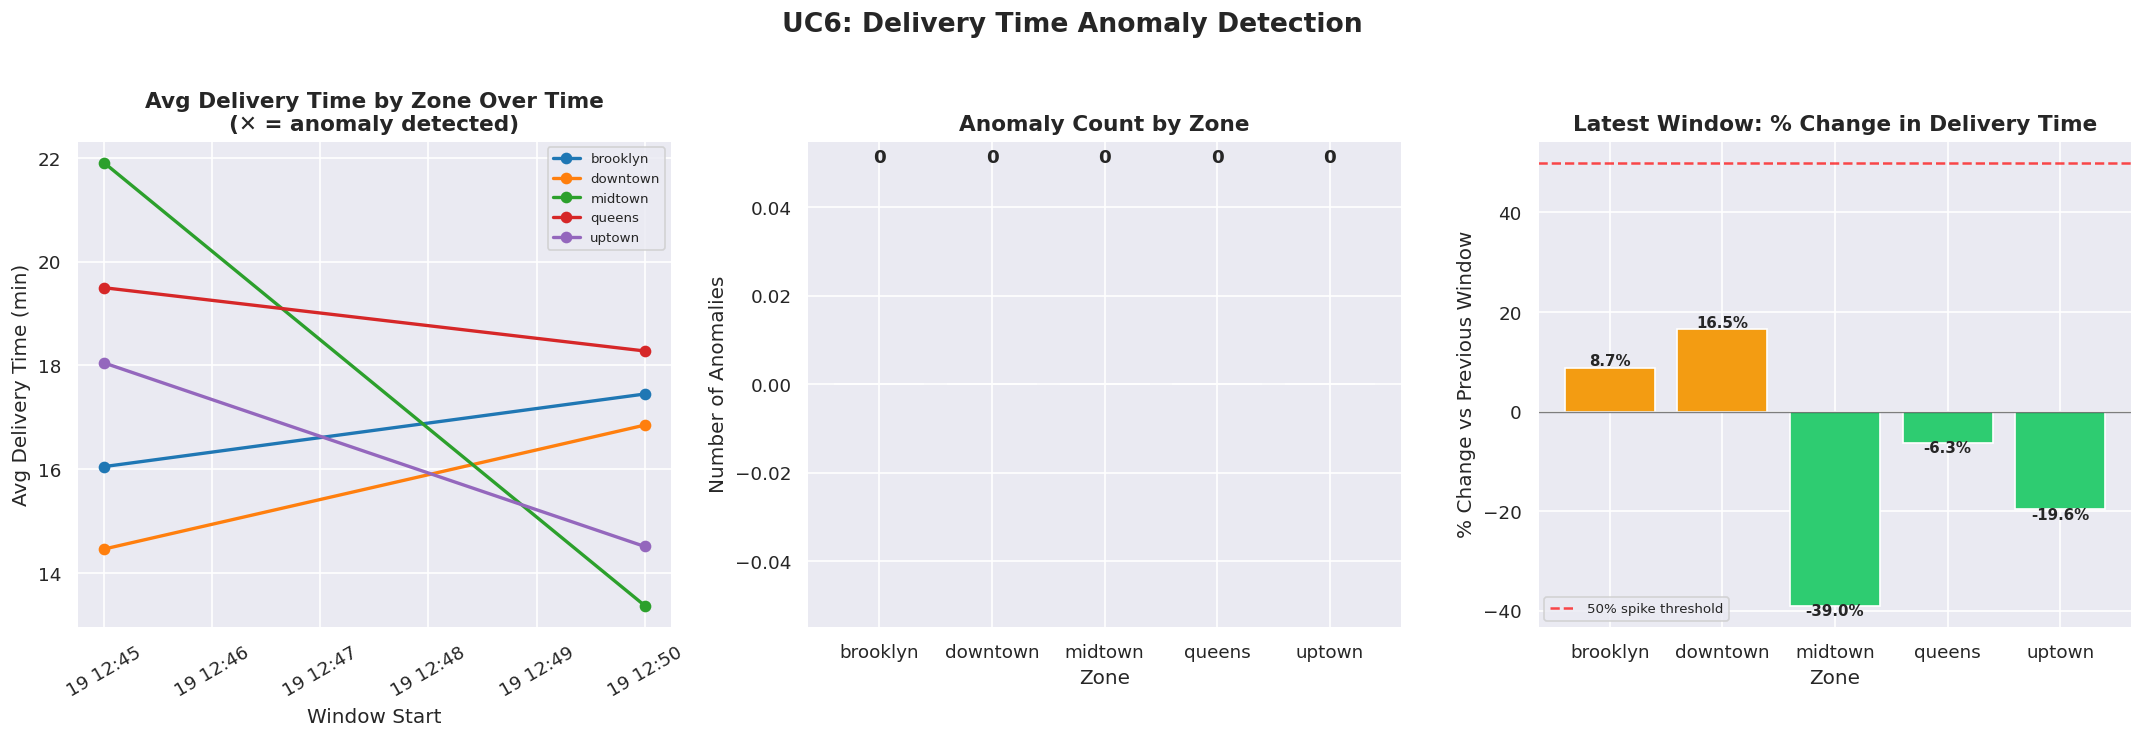

Saved: uc6_anomaly_detection.png


In [92]:
uc6_pd = spark.read.parquet(f"{base_path}/uc6_anomaly_raw")

if uc6_pd.count() == 0:
    print("No anomaly data yet — wait a few more minutes and rerun.")
else:
    from pyspark.sql.window import Window
    from pyspark.sql.functions import lag

    zone_win = Window.partitionBy("zone_id").orderBy("window_start")

    uc6_flagged = (
        uc6_pd
        .withColumn("prev_avg", lag("avg_delivery_min", 1).over(zone_win))
        .withColumn("pct_change",
            _round((col("avg_delivery_min") - col("prev_avg")) / col("prev_avg") * 100, 1))
        .withColumn("is_anomaly",
            (col("avg_delivery_min") > col("prev_avg") * 1.5) & col("prev_avg").isNotNull())
    ).toPandas().fillna(0)

    print("=== Delivery Time Anomalies Detected ===")
    anomalies = uc6_flagged[uc6_flagged["is_anomaly"] == True]
    print(f"Total anomalies found: {len(anomalies)}")
    print(anomalies[["zone_id", "window_start", "prev_avg", "avg_delivery_min", "pct_change"]])

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    if uc6_flagged.empty:
        for ax in axes:
            ax.text(0.5, 0.5, "No anomaly data yet\nWait a few more minutes and rerun",
                    ha="center", va="center", fontsize=13, color="gray",
                    transform=ax.transAxes)
    else:
        # Chart 1 — Avg delivery time per zone over time, anomalies highlighted
        zones = uc6_flagged["zone_id"].unique()
        colors = sns.color_palette("tab10", len(zones))

        for zone, color in zip(zones, colors):
            zone_data = uc6_flagged[uc6_flagged["zone_id"] == zone].sort_values("window_start")
            axes[0].plot(zone_data["window_start"], zone_data["avg_delivery_min"],
                         marker="o", label=zone, color=color, linewidth=2)
            # Highlight anomaly points
            anomaly_points = zone_data[zone_data["is_anomaly"] == True]
            if not anomaly_points.empty:
                axes[0].scatter(anomaly_points["window_start"], anomaly_points["avg_delivery_min"],
                                color="red", s=120, zorder=5, marker="X")

        axes[0].set_title("Avg Delivery Time by Zone Over Time\n(✕ = anomaly detected)",
                          fontsize=13, fontweight="bold")
        axes[0].set_xlabel("Window Start")
        axes[0].set_ylabel("Avg Delivery Time (min)")
        axes[0].legend(fontsize=8)
        axes[0].tick_params(axis="x", rotation=30)

        # Chart 2 — Anomaly count per zone
        anomaly_counts = uc6_flagged.groupby("zone_id")["is_anomaly"].sum().reset_index()
        anomaly_counts.columns = ["zone_id", "anomaly_count"]
        anomaly_counts = anomaly_counts.sort_values("anomaly_count", ascending=False)

        bar_colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in anomaly_counts["anomaly_count"]]
        bars = axes[1].bar(anomaly_counts["zone_id"], anomaly_counts["anomaly_count"], color=bar_colors)
        axes[1].set_title("Anomaly Count by Zone", fontsize=13, fontweight="bold")
        axes[1].set_xlabel("Zone")
        axes[1].set_ylabel("Number of Anomalies")
        for bar, val in zip(bars, anomaly_counts["anomaly_count"]):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                         str(int(val)), ha="center", fontsize=11, fontweight="bold")

        # Chart 3 — % change in delivery time per zone (latest window vs previous)
        latest = (uc6_flagged
                  .sort_values("window_start", ascending=False)
                  .groupby("zone_id")
                  .first()
                  .reset_index()[["zone_id", "pct_change", "is_anomaly"]])

        change_colors = ["#e74c3c" if row["is_anomaly"] else "#f39c12" if row["pct_change"] > 0
                         else "#2ecc71" for _, row in latest.iterrows()]
        bars2 = axes[2].bar(latest["zone_id"], latest["pct_change"], color=change_colors)
        axes[2].axhline(y=0, color="black", linewidth=0.8, alpha=0.5)
        axes[2].axhline(y=50, color="red", linestyle="--", alpha=0.7, label="50% spike threshold")
        axes[2].set_title("Latest Window: % Change in Delivery Time", fontsize=13, fontweight="bold")
        axes[2].set_xlabel("Zone")
        axes[2].set_ylabel("% Change vs Previous Window")
        axes[2].legend(fontsize=8)
        for bar, val in zip(bars2, latest["pct_change"]):
            axes[2].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + (0.5 if val >= 0 else -2),
                         f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

    plt.suptitle("UC6: Delivery Time Anomaly Detection", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("uc6_anomaly_detection.png", bbox_inches="tight")
    plt.show()
    print("Saved: uc6_anomaly_detection.png")

LAST CELL TO RUN

In [55]:
# BLOCK 13 — Active queries + cleanup (Cell 23 pattern)
# =============================================================================
for q in spark.streams.active:
    print("active:", q.name, "id=" + q.id)

# To stop individual queries (run these when ready to shut down):
query_orders_parquet.stop()
query_couriers_parquet.stop()
query_orders_mem.stop()
query_couriers_mem.stop()

# Or stop everything at once:
# for q in spark.streams.active:
#     q.stop()
# spark.stop()


active: None id=87c8dca8-1c87-44ea-b104-3218a82d65f8
active: None id=aea33342-e137-4df2-94a4-8c60fe99ec3e
active: uc6_anomaly_raw id=b3cd5c1e-c51a-4fb7-abf3-6e163f5bdf2c
active: uc2_cancellation_rate id=f7553daa-f4de-4b4f-ab48-59ad040ef537
active: uc5_demand_supply id=6b979b16-9f0f-408a-83e4-4aa3fbb29210
active: uc4_courier_availability id=5f2304d1-0e5c-45fc-ac85-683a0cd0652a
active: uc1_revenue_by_zone id=2917b6b0-0392-44ab-8949-048273607bcc
active: uc3_delivery_duration id=7d8c7773-d5a0-4e84-9dc1-a3eea3554a1b
